## Assignment 1 - MovieLens Dataset Exploration
### Sruthilaya Umasankari Soma Shanmuga Sundaram, Date of Submission 17/05/2026

In [15]:
import pandas as pd

#Loading the datasets
ratings = pd.read_csv('dataset/ratings.dat', sep='::', engine='python',
                      names=['UserID', 'MovieID', 'Rating', 'Timestamp'])

movies = pd.read_csv('dataset/movies.dat', sep='::', engine='python',
                     names=['MovieID', 'Title', 'Genres'], encoding='latin-1')

users = pd.read_csv('dataset/users.dat', sep='::', engine='python',
                    names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip'])

### Basic Data Exploration

In [16]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)
print("Users Shape:" , users.shape)

Ratings Shape: (1000209, 4)
Movies Shape: (3883, 3)
Users Shape: (6040, 5)


In [ ]:
print(ratings.head()) #ratings dataset has 4 columns: UserID, MovieID, Rating, Timestamp
print(movies.head()) #movies dataset has 3 columns: MovieID, Title (Title has release year as part of it), Genres (Genres are separated by '|')
print(users.head())  #users dataset has 3 columns: UserID, Age, Gender

   UserID  MovieID  Rating  Timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291
   MovieID                               Title                        Genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   UserID Gender  Age  Occupation    Zip
0       1      F    1          10  48067
1       2      M   56          16  70072
2       3      M   25          15  55117
3       4      M   45           7  02460
4       5      M   25          20  55455


In [ ]:
#Checking if there are any missing values in the datasets
# Insight: we can see that there are no null values in any of the datasets
print("Null in ratings:", ratings.isnull().sum().sum())
print("Null in movies:", movies.isnull().sum().sum())
print("Null in users:", users.isnull().sum().sum())

Null in ratings: 0
Null in movies: 0
Null in users: 0


In [ ]:
#Checking the datatypes of the columns in each dataset
#Insight: we can see that all the columns have the correct datatypes
print("Ratings dtypes:\n", ratings.dtypes)
print("Movies dytypes:\n",movies.dtypes)
print("Users dtypes:\n",users.dtypes)

Ratings dtypes:
 UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64
dtype: object
Movies dytypes:
 MovieID     int64
Title      object
Genres     object
dtype: object
Users dtypes:
 UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip           object
dtype: object


In [35]:
print(ratings['Rating'].describe()) #summary satistics show avg rating is around 3.5.
ratings['Rating'].value_counts().sort_index() #here we can see that the most common rating is 4, followed by 3 and 5.

count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64


Rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

In [ ]:
#users stats
print("Age Breakdown:", users['Age'].value_counts().sort_index()) #most common age group is 25-34, followed by 35-44 and 18-24
print("Gender Breakdown:", users['Gender'].value_counts().sort_index())#male users are dominant which shows a bias which would affect the genralisation of the model.

Age Breakdown: Age
1      222
18    1103
25    2096
35    1193
45     550
50     496
56     380
Name: count, dtype: int64
Gender Breakdown: Gender
F    1709
M    4331
Name: count, dtype: int64


In [42]:
#identifying which movies have more ratings and least ratings
movies_ratings_count = ratings.groupby('MovieID')['Rating'].count()
print("Movies with most ratings:\n", movies_ratings_count.sort_values(ascending=False).head())
print("Movies with least ratings:\n", movies_ratings_count.sort_values(ascending=True).head())

Movies with most ratings:
 MovieID
2858    3428
260     2991
1196    2990
1210    2883
480     2672
Name: Rating, dtype: int64
Movies with least ratings:
 MovieID
826     1
1852    1
3890    1
3065    1
1470    1
Name: Rating, dtype: int64


In [51]:
#how many unique genres are there
all_genres = movies['Genres'].str.split('|').explode().unique()
print("Unique Genres:", all_genres)
print("Total unique genres:", len(all_genres))

Unique Genres: ['Animation' "Children's" 'Comedy' 'Adventure' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Sci-Fi' 'Documentary' 'War'
 'Musical' 'Mystery' 'Film-Noir' 'Western']
Total unique genres: 18


#### Q1 - To find mean ratings by men aged above 25, per genre
Output Insight - The Genre "Film-Noir" has ~4 mean rating than all other Genres with ~3 mean rating shows Men above age 25 prefer this Genre more. Recommendation insight obtained here. Extended the same analysis for Female abv age 25 and the result shows "Film-Noir" is generally liked Genre in this age group irrespective of Gender.

In [44]:
men_abv_25 = users[(users['Gender'] == 'M') & (users['Age'] > 25)] #filtering users above 25 years of age
merged_data= ratings.merge(men_abv_25, on='UserID') #merging the ratings and users df
merged_data= merged_data.merge(movies, on='MovieID') #merging the above df with movies df
#grouping data by genre and calculating the mean rating for each genre
merged_data['Genre']=merged_data['Genres'].str.split('|')
merged_data=merged_data.explode('Genre') #splitting the genres and exploding it to have one genre per row
result=merged_data.groupby('Genre')['Rating'].mean().sort_values(ascending=False) #calculating the mean rating for each genre
print(result)


Genre
Film-Noir      4.117140
Documentary    3.950192
War            3.940634
Drama          3.812309
Crime          3.764249
Mystery        3.759347
Animation      3.721569
Western        3.708494
Musical        3.700242
Romance        3.659748
Thriller       3.644025
Comedy         3.565456
Action         3.554547
Adventure      3.538637
Sci-Fi         3.509693
Fantasy        3.490408
Children's     3.475314
Horror         3.241089
Name: Rating, dtype: float64


In [56]:
female_abv_25 = users[(users['Gender']=='F')&(users['Age']>25)]
female_abv_25 = ratings.merge(female_abv_25, on='UserID')
female_abv_25 = movies.merge(female_abv_25, on='MovieID')
female_abv_25['Genres'] = female_abv_25['Genres'].str.split('|')
female_abv_25 = female_abv_25.explode('Genres')
female_abv_25.groupby('Genres')['Rating'].mean().sort_values(ascending=False)

Genres
Film-Noir      4.064204
War            3.976948
Documentary    3.946574
Musical        3.879710
Drama          3.835724
Animation      3.803525
Mystery        3.801381
Romance        3.766936
Crime          3.753047
Western        3.692266
Children's     3.668804
Thriller       3.659867
Comedy         3.658881
Adventure      3.591242
Fantasy        3.580167
Action         3.559380
Sci-Fi         3.503287
Horror         3.295800
Name: Rating, dtype: float64

#### Q2. Top 5 movies which is most reviewed (ie, has more people rating it)
Output Insight: The most rated movie is "American Beauty" followed by "Star Wars: Episode IV - A New Hope" and "Star Wars: Episode V - The Empire Strikes Back" which shows that these movies are very popular among the users.
American Beauty ranks #1 due to the recency of release when the data was collected and it had an Oscar hype, while Star Wars collectively exceeds it by 3x when franchise ratings are combined.

In [59]:
ratings_count= ratings.groupby('MovieID')['Rating'].count()
print(ratings_count.sort_values(ascending=False).head())

MovieID
2858    3428
260     2991
1196    2990
1210    2883
480     2672
Name: Rating, dtype: int64


In [62]:
top5= ratings_count.sort_values(ascending=False).head().reset_index()
top5.columns=['MovieID', 'RatingCount']
top5= top5.merge(movies, on='MovieID')
print("Top 5 Movies by Rating Count:")
print(top5[['Title', 'RatingCount']])  

Top 5 Movies by Rating Count:
                                               Title  RatingCount
0                             American Beauty (1999)         3428
1          Star Wars: Episode IV - A New Hope (1977)         2991
2  Star Wars: Episode V - The Empire Strikes Back...         2990
3  Star Wars: Episode VI - Return of the Jedi (1983)         2883
4                               Jurassic Park (1993)         2672


In [66]:
top5_ids = top5['MovieID'].tolist()
top5_ratings = ratings[ratings['MovieID'].isin(top5_ids)]
top5_ratings = top5_ratings.merge(movies[['MovieID', 'Title']], on='MovieID')
top5_ratings['YearMonth'] = top5_ratings['Date'].dt.to_period('M')
timeline = top5_ratings.groupby(['Title', 'YearMonth'])['Rating'].count()
avg_date = top5_ratings.groupby('Title')['Date'].mean()
print(avg_date.sort_values())

Title
Star Wars: Episode VI - Return of the Jedi (1983)       2000-10-02 04:14:25.911550464
Star Wars: Episode V - The Empire Strikes Back (1980)   2000-10-04 22:26:35.886956416
Star Wars: Episode IV - A New Hope (1977)               2000-10-05 14:04:10.400200576
American Beauty (1999)                                  2000-10-06 23:41:25.196324352
Jurassic Park (1993)                                    2000-10-10 03:20:55.602919168
Name: Date, dtype: datetime64[ns]


In [67]:
ratings['Date'] = pd.to_datetime(ratings['Timestamp'], unit='s')
print(ratings['Date'].min())  # when did ratings start?
print(ratings['Date'].max())  # when did they end?

2000-04-25 23:05:32
2003-02-28 17:49:50


#### Q3. Finding Average Rating by Age Groups
Output Insight: Older users rate more generously than younger users consistently, since older people tend to research and pick the movie they would mostly like so they end up rating higher. Also users beyond age 56 havn't rated in this dataset, so no average rating for group >=70.

In [72]:
#creating the age groups mapping
age_map = {
    1:  '1. <=18',
    18: '2. 19-30',
    25: '2. 19-30',
    35: '3. 31-50',
    45: '3. 31-50',
    50: '4. 51-70',
    56: '4. 51-70'
}
users['AgeGroup'] = users['Age'].map(age_map)
print(users['AgeGroup'].value_counts().sort_index())

AgeGroup
1. <=18      222
2. 19-30    3199
3. 31-50    1743
4. 51-70     876
Name: count, dtype: int64


In [74]:
merged_age = ratings.merge(users, on='UserID')
avg_rating_by_age = merged_age.groupby('AgeGroup')['Rating'].mean()
print(avg_rating_by_age)

AgeGroup
1. <=18     3.549520
2. 19-30    3.533299
3. 31-50    3.624050
4. 51-70    3.732677
Name: Rating, dtype: float64


In [80]:
print("Users with age code above 56:", (users['Age'] > 56).sum()) #therefore there are no users above 70 years of age.

Users with age code above 56: 0


#### Q4. Average rating of Toy Story 2 vs all movies the same year by the age groups 1. <=18 2. >=19 and <=45 3. >45
Output Insight: 

In [ ]:
movies[movies['Title'].str.contains('Toy Story')] #Toy Story 2 release year is 1999.

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
3045,3114,Toy Story 2 (1999),Animation|Children's|Comedy


In [84]:
#List of movies released in 1999
movies_1999 = movies[movies['Title'].str.contains('1999')]
print(f"Total movies from 1999: {len(movies_1999)}")
movies_1999.head()

Total movies from 1999: 283


,MovieID,Title,Genres
2166,2235,One Man's Hero (1999),Drama|War
2367,2436,Tea with Mussolini (1999),Comedy
2376,2445,At First Sight (1999),Drama
2377,2446,In Dreams (1999),Thriller
2378,2447,Varsity Blues (1999),Comedy|Drama


In [86]:
age_map_q4 = {
    1:  'a. Under 18',
    18: 'b. 19 to 45',
    25: 'b. 19 to 45',
    35: 'b. 19 to 45',
    45: 'c. Above 45',
    50: 'c. Above 45',
    56: 'c. Above 45'
}
users['AgeGroup_Q4'] = users['Age'].map(age_map_q4)

In [87]:
merged_rating_1999= ratings.merge(movies_1999, on="MovieID")
merged_rating_1999= merged_rating_1999.merge(users[["UserID", "AgeGroup_Q4"]], on="UserID")
print(merged_rating_1999.head())

   UserID  MovieID  Rating  Timestamp                Date  Year_Rated  \
0       1     2687       3  978824268 2001-01-06 23:37:48        2001   
1       1     3186       4  978300019 2000-12-31 22:00:19        2000   
2       1     2762       4  978302091 2000-12-31 22:34:51        2000   
3       1     3114       4  978302174 2000-12-31 22:36:14        2000   
4       2     2628       3  978300051 2000-12-31 22:00:51        2000   

                                              Title  \
0                                     Tarzan (1999)   
1                          Girl, Interrupted (1999)   
2                           Sixth Sense, The (1999)   
3                                Toy Story 2 (1999)   
4  Star Wars: Episode I - The Phantom Menace (1999)   

                            Genres  AgeGroup_Q4  
0             Animation|Children's  a. Under 18  
1                            Drama  a. Under 18  
2                         Thriller  a. Under 18  
3      Animation|Children's|Co

In [88]:
Q4_result = merged_rating_1999.groupby('AgeGroup_Q4')['MovieID'].nunique()
print(Q4_result)

AgeGroup_Q4
a. Under 18    221
b. 19 to 45    270
c. Above 45    253
Name: MovieID, dtype: int64


#### Extending the analysis to find how did Toy Story fair against other movies released in 1999
Insight:Toy Story 2 (TS2) was watched by more people in 19-45 age group more than <=18 age group, which could be result of parents accompanying their kids to the shows registering their rating. Also the average rating for TS2 is ~0.7 higher than all 1999 movies average rating which confirms the universal appeal for the movie.


In [ ]:
toystory2 = ratings[ratings['MovieID'] == 3114]
toystory2 = toystory2.merge(users[['UserID', 'AgeGroup_Q4']], on='UserID')

# count of number of ratings and average rating for Toy Story 2 by age group
toystory2_analysis = toystory2.groupby('AgeGroup_Q4')['Rating'].agg(['count', 'mean'])
toystory2_analysis.columns = ['NumRatings', 'AvgRating']
print(toystory2_analysis)

             NumRatings  AvgRating
AgeGroup_Q4                       
a. Under 18          99   4.202020
b. 19 to 45        1251   4.231015
c. Above 45         235   4.161702


In [91]:
#Identifying the average rating for all 1999 movies by age group
avg_1999 = merged_rating_1999.groupby('AgeGroup_Q4')['Rating'].mean()

# Addding the comparison column
toystory2_analysis['Avg_1999_Movies'] = avg_1999
toystory2_analysis['AboveAvg?'] = toystory2_analysis['AvgRating'] > toystory2_analysis['Avg_1999_Movies']
print(toystory2_analysis)

             NumRatings  AvgRating  Avg_1999_Movies  AboveAverage?  AboveAvg?
AgeGroup_Q4                                                                  
a. Under 18          99   4.202020         3.525049           True       True
b. 19 to 45        1251   4.231015         3.486012           True       True
c. Above 45         235   4.161702         3.542485           True       True


#### Q5. Write a function that takes user_id + movie_id and returns all movies rated the same way

Output Insight:

In [92]:
def similarly_rated_movies(user_id, movie_id):
    #find the rating the user gave to the given movie
    given_rating = ratings[
        (ratings['UserID'] == user_id) & 
        (ratings['MovieID'] == movie_id)
    ]['Rating'].values
    
    #edge case to handle where user hasn't rated this movie
    if len(given_rating) == 0:
        return f"User {user_id} has not rated MovieID {movie_id}"
    
    given_rating = given_rating[0]
    print(f"User {user_id} rated this movie: {given_rating} stars")
    
    #finding all other movies rated the same way
    similar = ratings[
        (ratings['UserID'] == user_id) & 
        (ratings['Rating'] == given_rating) & 
        (ratings['MovieID'] != movie_id)
    ]
    
    similar = similar.merge(movies[['MovieID', 'Title']], on='MovieID')
    
    return similar[['Title', 'Rating']]

Test to validate the functin

In [97]:
# Test 1: Normal case
print("TEST 1 - Valid user and movie:")
print(similarly_rated_movies(1, 3114))

# Test 2: User hasn't rated the movie
print("\nTEST 2 - User who hasn't rated Toy Story 2:")
print(similarly_rated_movies(999, 3114))

TEST 1 - Valid user and movie:
User 1 rated this movie: 4 stars
                                        Title  Rating
0                      Erin Brockovich (2000)       4
1      Snow White and the Seven Dwarfs (1937)       4
2                    Wizard of Oz, The (1939)       4
3                                 Gigi (1958)       4
4               Miracle on 34th Street (1947)       4
5             Ferris Bueller's Day Off (1986)       4
6                            Airplane! (1980)       4
7                                Bambi (1942)       4
8                                  Big (1988)       4
9           E.T. the Extra-Terrestrial (1982)       4
10                             Titanic (1997)       4
11                             Ponette (1996)       4
12                                Antz (1998)       4
13                   Girl, Interrupted (1999)       4
14                            Hercules (1997)       4
15                             Aladdin (1992)       4
16                

#### Q6. Interesting insights
1. Difference between users who rate for 500+ movies and the ones who rate for <100 movies. Finding if they rate differently.
    - Insight : Result shows Prolific raters(500+ movies rater) score average ~0.4 lower than than casual viewers.This suggests that heavy viewers have developed higher standards over time.

In [99]:
user_rating_counts = ratings.groupby('UserID')['Rating'].count()

def rater_type(n):
    if n < 100:
        return 'Casual (<100)'
    elif n < 500:
        return 'Moderate (100-500)'
    else:
        return 'Prolific (500+)'

user_types = user_rating_counts.apply(rater_type).reset_index()
user_types.columns = ['UserID', 'RaterType']
print(user_types['RaterType'].value_counts())

RaterType
Casual (<100)         3095
Moderate (100-500)    2546
Prolific (500+)        399
Name: count, dtype: int64


In [100]:
merged_user_types = ratings.merge(user_types, on='UserID')
user_types_ratings = merged_user_types.groupby('RaterType')['Rating'].agg(['mean', 'count'])
user_types_ratings.columns = ['AvgRating', 'TotalRatings']
print(user_types_ratings.sort_values('AvgRating', ascending=False))

                    AvgRating  TotalRatings
RaterType                                  
Casual (<100)        3.774183        152907
Moderate (100-500)   3.630916        556993
Prolific (500+)      3.385424        290309


2. Movies with very few ratings but very high average to find underrated good films which the algorithm wouldn't recommend.
- Step1: To find the average ratings count (not skewed by super hit movie ratings) to determine the range which we can consider a movie as viewed enough to be taken into consideration for this task.
- Step2: using the range (33 (25th percentile) - 124 (median ratings count)) we find the hidden gems ie underrated great finds.

Insight: We have found 46 hidden gems between 33-124 ratings with 4.0+ average topped by Kurosawa's Sanjuro (4.61) and Satyajit Ray's Apu Trilogy, suggesting world cinema masterpieces are underrepresented in popularity-based recommendation systems

In [101]:
#finding average number of ratting per movie
ratings_per_movie = ratings.groupby('MovieID')['Rating'].count()
print(f"Mean ratings per movie: {ratings_per_movie.mean():.0f}")
print(f"Median ratings per movie: {ratings_per_movie.median():.0f}")
print(f"Min: {ratings_per_movie.min()}")
print(f"Max: {ratings_per_movie.max()}")
print(f"25th percentile: {ratings_per_movie.quantile(0.25):.0f}")

Mean ratings per movie: 270
Median ratings per movie: 124
Min: 1
Max: 3428
25th percentile: 33


In [102]:
movie_stats = ratings.groupby('MovieID')['Rating'].agg(['count', 'mean'])
movie_stats.columns = ['NumRatings', 'AvgRating']

hidden_gems = movie_stats[
    (movie_stats['NumRatings'] >= 33) & 
    (movie_stats['NumRatings'] <= 124) &
    (movie_stats['AvgRating'] >= 4.0)
]

hidden_gems = hidden_gems.merge(movies[['MovieID', 'Title', 'Genres']], on='MovieID')
hidden_gems = hidden_gems.sort_values('AvgRating', ascending=False)
print(f"Total hidden gems found: {len(hidden_gems)}")
print(hidden_gems.head(10))

Total hidden gems found: 46
    MovieID  NumRatings  AvgRating  \
30     2905          69   4.608696   
9       670          56   4.410714   
8       668          47   4.404255   
3       326          61   4.344262   
41     3470          92   4.326087   
25     2360         117   4.307692   
34     2937         104   4.288462   
42     3679          62   4.274194   
4       363          62   4.258065   
32     2925          57   4.228070   

                                                Title            Genres  
30                                     Sanjuro (1962)  Action|Adventure  
9              World of Apu, The (Apur Sansar) (1959)             Drama  
8                              Pather Panchali (1955)             Drama  
3                             To Live (Huozhe) (1994)             Drama  
41                                 Dersu Uzala (1974)   Adventure|Drama  
25                   Celebration, The (Festen) (1998)             Drama  
34                       Palm Beach

3. Heatmap that shows movie genres performance by age groups
- Insight: Film-Noir is the most rated genre across all ages (4.04-4.16), while Horror is universally the lowest. Surprisingly, older audiences rate animation significantly higher (3.48 --> 3.77), suggesting nostalgia plays a role in appreciation.

In [ ]:
# Reuse merged data from Q1 but add age groups
merged_heatmap = ratings.merge(users[['UserID', 'AgeGroup']], on='UserID')
merged_heatmap = merged_heatmap.merge(movies, on='MovieID')
merged_heatmap['Genres'] = merged_heatmap['Genres'].str.split('|')
merged_heatmap = merged_heatmap.explode('Genres')

heatmap_data = merged_heatmap.pivot_table(
    values='Rating',
    index='Genres',
    columns='AgeGroup',
    aggfunc='mean'
)
print(heatmap_data)

AgeGroup      1. <=18  2. 19-30  3. 31-50  4. 51-70
Genres                                             
Action       3.506385  3.451342  3.535457  3.611131
Adventure    3.449975  3.431615  3.519214  3.635071
Animation    3.476113  3.671556  3.739051  3.771750
Children's   3.241642  3.374271  3.520975  3.577882
Comedy       3.497491  3.480548  3.570542  3.648259
Crime        3.710170  3.676425  3.738624  3.818342
Documentary  3.730769  3.927571  3.957411  3.925153
Drama        3.794735  3.725100  3.783083  3.898852
Fantasy      3.317647  3.417415  3.496238  3.566504
Film-Noir    4.145455  4.042862  4.077382  4.155996
Horror       3.254184  3.191129  3.272028  3.185036
Musical      3.568306  3.599641  3.728646  3.831794
Mystery      3.631522  3.585455  3.715628  3.887595
Romance      3.621284  3.542918  3.662005  3.778892
Sci-Fi       3.478698  3.438230  3.496485  3.543526
Thriller     3.550373  3.522541  3.622776  3.713000
War          3.895437  3.844863  3.919786  4.009020
Western     

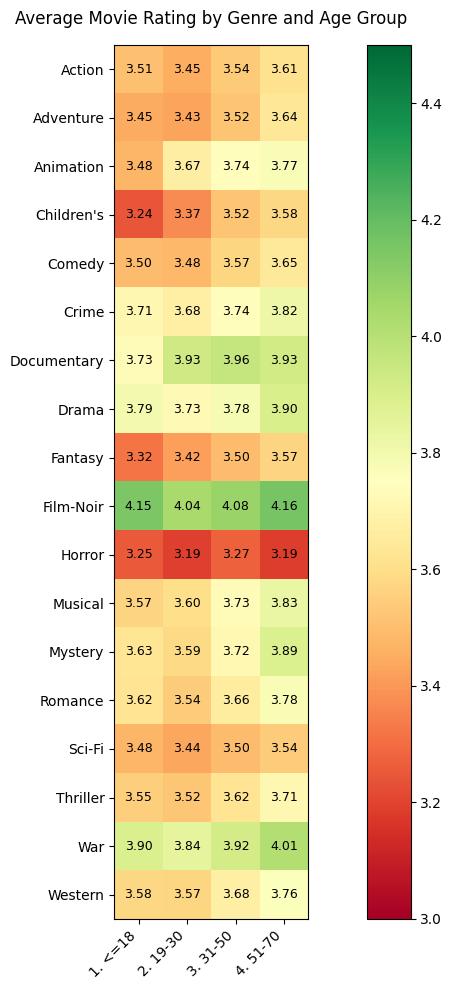

In [110]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

data = heatmap_data.values
genres = heatmap_data.index.tolist()
age_groups = heatmap_data.columns.tolist()

im = ax.imshow(data, cmap='RdYlGn', vmin=3.0, vmax=4.5)

ax.set_xticks(np.arange(len(age_groups)))
ax.set_yticks(np.arange(len(genres)))
ax.set_xticklabels(age_groups, rotation=45, ha='right')  # ← rotated
ax.set_yticklabels(genres)

for i in range(len(genres)):
    for j in range(len(age_groups)):
        ax.text(j, i, f'{data[i,j]:.2f}',
                ha='center', va='center', fontsize=9)

plt.colorbar(im)
plt.title('Average Movie Rating by Genre and Age Group', pad=15)
plt.tight_layout()
plt.show()